# MIOFlow — Spatial Data Preprocessing

## Workflow
1. Load pre-processed Axalotl Spatial Transxriptomics

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
from os import listdir
from os.path import isfile, join
import re

## 1. Load Data

In [2]:
adata = sc.read_h5ad("Axolotl_batch_corrected.h5ad")

/home/jcr222/workspace/mioflow/MIOFlow/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
# compute symmetric knn graph
from sklearn.neighbors import kneighbors_graph as knn
from scipy.sparse.linalg import matrix_power as sparse_matpow
import networkx as nx

# k for knn-graph
k = 5

# numper of hops for final graph
n = 3

# highest allowed knn-dist
dmax = 500

Gs = []
G_hops = []
for b in np.unique(adata.obs['Batch']):
    coords = adata[adata.obs['Batch'] == b].obsm['spatial']
    G = knn(coords, k, mode='distance')
    G[G > dmax] = 0
    G = G > 0
    G.setdiag(True)
    G = sparse_matpow(G, n)
    G.setdiag(False)
    Gs.append(
        np.stack(G.nonzero(), axis=-1)
        )

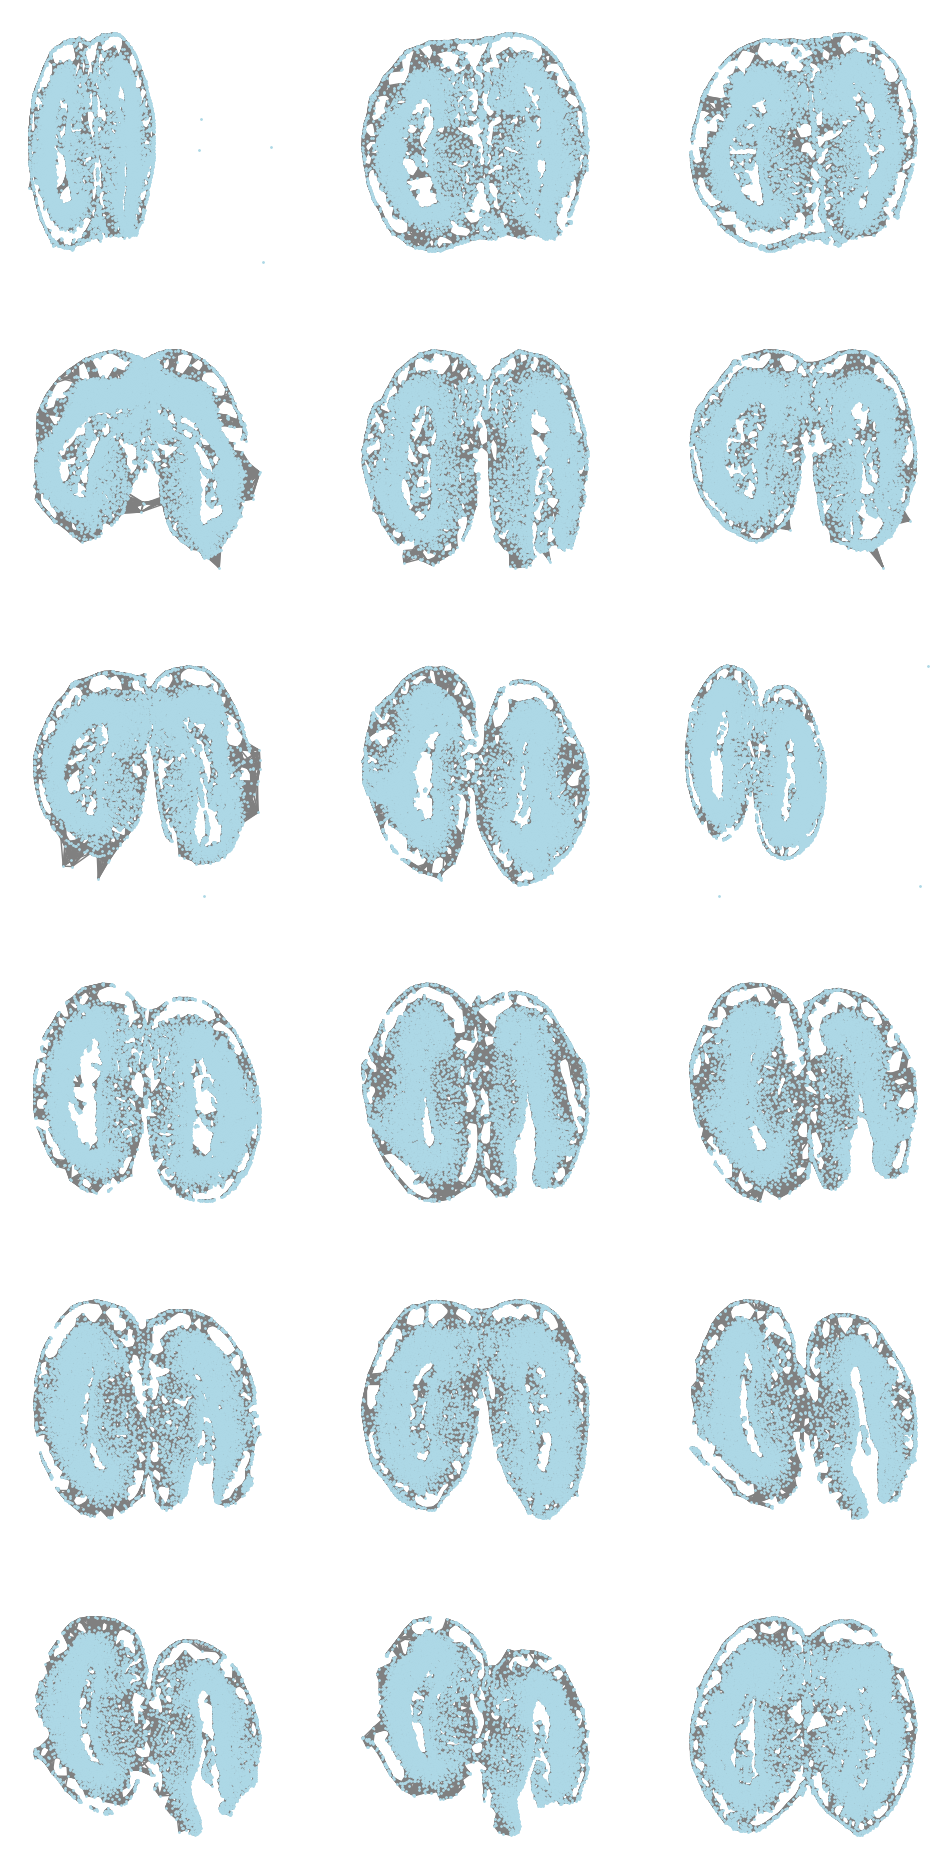

In [4]:
# sanity check - visualize graphs
fig, axs = plt.subplots(6, 3, figsize = (12, 24))
axs = axs.flatten()

for i, b in enumerate(np.unique(adata.obs['Batch'])):

    coords = adata[adata.obs['Batch'] == b].obsm['spatial']

    G = nx.Graph()
    G.add_nodes_from(range(len(coords)))
    G.add_edges_from(Gs[i])

    nx.draw(G, pos=coords, node_color='lightblue', edge_color='gray', node_size=1, ax=axs[i])

plt.show()

In [7]:
import pickle as pkl

with open('Axolotl_spatial_adjacency.pkl', 'wb') as f:
    pkl.dump(Gs, f)

In [8]:
# load ligand:receptor pair list and MAGIC imputed expression
LR_pairs = pd.read_csv("../../data/ARTISTA_LR_pairs.csv")
lr_pairs = list(LR_pairs['Ligand'])  + list(LR_pairs['Receptor'])

with open('../../data/Axolotl_LR_Magic.pkl', 'rb') as f:
    lr_magic = pkl.load(f)

In [9]:
import torch

def lr_aggregate(A, B, edge_index):
    src = edge_index[:, 0]
    dst = edge_index[:, 1]

    # Sum B over neighbors of each i
    B_sum = torch.zeros_like(B)
    B_sum.index_add_(0, src, B[dst])

    # Elementwise multiply once per node
    out = A * B_sum

    return out

def cell_type_aggregate(labels, edge_index):
    src = edge_index[:, 0]
    dst = edge_index[:, 1]

    count = torch.zeros_like(labels)
    count.index_add_(0, src, labels[dst])

    count = count + labels

    return count

def geneformer_aggregate(emb, edge_index):
    src = edge_index[:, 0]
    dst = edge_index[:, 1]

    mean = torch.zeros_like(emb)
    mean.index_add_(0, src, emb[dst])

    degree = torch.zeros(len(emb), dtype=mean.dtype)
    degree.index_add_(0, src, torch.ones_like(src, dtype=mean.dtype))
    degree = degree.clamp(min=1)

    mean = mean / degree.unsqueeze(1)

    return mean

In [10]:
ligands = torch.from_numpy(np.array(lr_magic[lr_pairs[:len(lr_pairs)//2]]))
receptors = torch.from_numpy(np.array(lr_magic[lr_pairs[len(lr_pairs)//2:]]))
celltype = torch.nn.functional.one_hot(torch.tensor(np.unique(adata.obs['Annotation'], return_inverse=True)[1]))

lr_feats = np.zeros((adata.shape[0], ligands.shape[1]))
cell_type_counts = np.zeros((adata.shape[0], celltype.shape[1]))

for i, b in enumerate(np.unique(adata.obs['Batch'])):
    batch_inds = np.where(adata.obs['Batch'] == b)
    G = torch.tensor(Gs[i])
    
    batch_ligands = (ligands)[batch_inds]
    batch_receptors = receptors[batch_inds]

    batch_celltype = celltype[batch_inds]


    lr_feats[batch_inds] = lr_aggregate(batch_receptors, batch_ligands, G).numpy()
    cell_type_counts[batch_inds] = cell_type_aggregate(batch_celltype, G).numpy()

In [11]:
adata.obsm['LR_feats'] = lr_feats
adata.obsm['celltype_nbrhood'] = cell_type_counts
adata.write_h5ad('Axolotl_spatial_processed.h5ad')

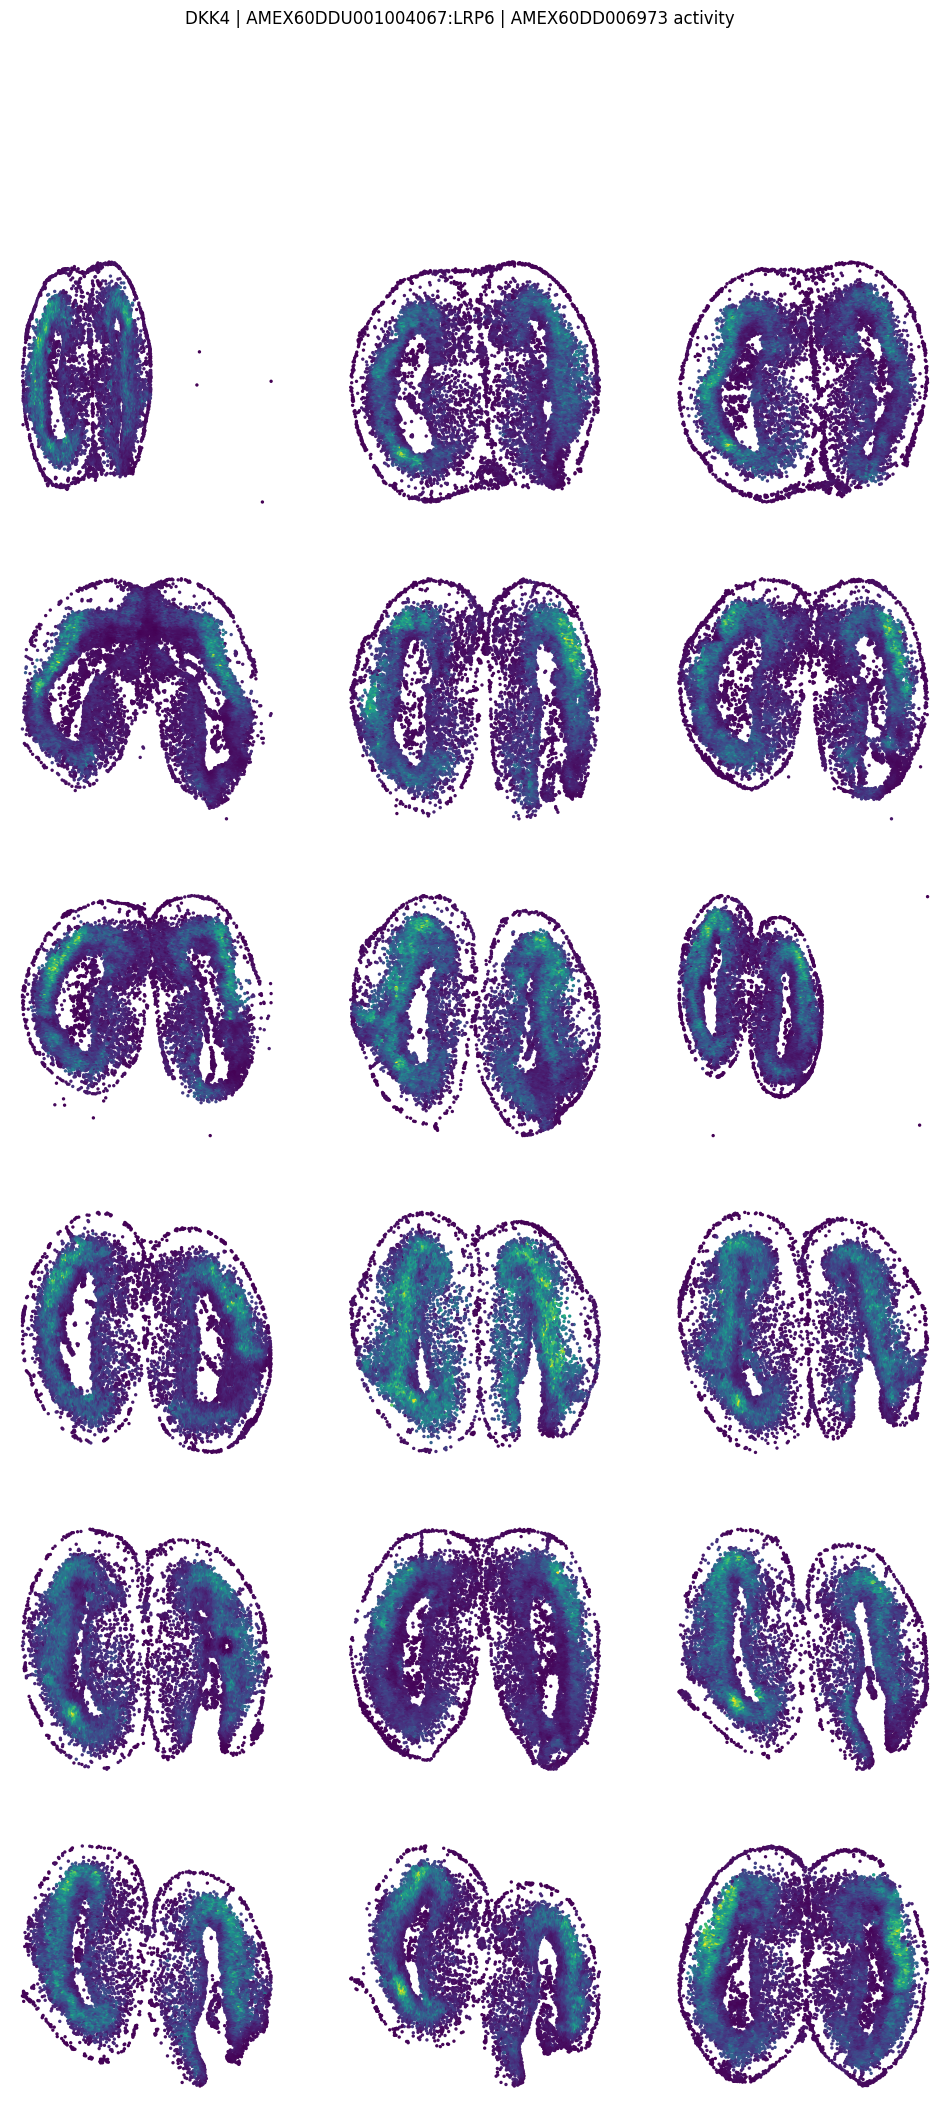

In [12]:
# sanity check, plot spatial LR feature
fig, axs = plt.subplots(6, 3, figsize = (12, 24))
axs = axs.flatten()


pind = 20
for i, b in enumerate(np.unique(adata.obs['Batch'])):

    subdata = adata[adata.obs['Batch'] == b]

    coords = subdata.obsm['spatial']

    axs[i].scatter(*coords.T, c=subdata.obsm['LR_feats'][:, pind], s=2)
    axs[i].set_axis_off()

fig.suptitle(f'{lr_pairs[pind]}:{lr_pairs[pind+len(lr_pairs)//2]} activity')

plt.show()

In [ ]:
# subset data to cell-types of interest in injured samples only
celltypes = ['reaEGC', 'rIPC1', 'rIPC2', 'rIPC3', 'rIPC4', 'IMN', 'nptxEX']
whichin = adata.obs['Annotation'].isin(celltypes)
subdata = adata[whichin]
subdata = subdata[subdata.obs['inj_uninj'] == 'inj']
subdata.obs['Annotation_grouped'] = subdata.obs['Annotation']
subdata.obs['Annotation_grouped'] = ['rIPCs' if np.max(np.equal(['rIPC1', 'rIPC2', 'rIPC3', 'rIPC4'], x)) else x for x in np.array(subdata.obs['Annotation'])]

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs[0].scatter(*subdata.obsm['X_phate_gene'].T, s=2, c=np.unique(subdata.obs['dpi'], return_inverse=True)[1], cmap='magma')
axs[0].set_title('gene PHATE colored by timepoint')
for c in np.unique(subdata.obs['Annotation_grouped']):
    axs[1].scatter(*subdata[subdata.obs['Annotation_grouped'] == c].obsm['X_phate_gene'].T, s=1, label=c)
    axs[1].legend()
axs[1].set_title('gene PHATE colored by cell type')
plt.show()

In [ ]:
subdata.write_h5ad('Axolotl_trajectory_subset.h5ad')

In [ ]:
# compute diffusion pseudotime

# set root cells as reaEGC
cands = np.where((subdata.obs['Annotation'] == "reaEGC") * (subdata.obs['dpi'] == 2))[0]
subdata.uns['iroot'] = cands[np.argmax((subdata.obsm['X_phate_gene'][cands] * np.array([-1, 0.2])[None,:]).sum(axis=1))]

In [ ]:
plt.scatter(*subdata.obsm['X_phate_gene'].T, s=2, c='black')
plt.scatter(*subdata.obsm['X_phate_gene'][subdata.uns['iroot']].T, s=50, c='red')
plt.title('root cell')
plt.show()

In [ ]:
sc.pp.neighbors(subdata, use_rep='X_pca_harmony')
sc.tl.diffmap(subdata)
sc.tl.dpt(subdata)

In [ ]:
nbins=5
plt.scatter(*subdata.obsm['X_phate_gene'].T, s=2, c=np.digitize(subdata.obs['dpt_pseudotime'], np.linspace(0, 1, nbins+1)), cmap='magma')
plt.show()